In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [116]:
df = pd.read_csv("csv/data.csv")
pd.set_option('display.max_columns', None)
# pd.reset_option('display.max_columns')
# Маржа = цена продажи - себестоимость

df = df.drop_duplicates()

df['date'] = pd.to_datetime(df["created_at"], errors='coerce', format='ISO8601')

df["margin"] = df["sale_price"] - df["cost"]
df["revenue"] = df["sale_price"]

df['return_flg'] = (~df['returned_at'].isna()).astype(int)
df_delivered = df[df['status'].str.strip().str.lower() == 'complete']
df_delivered_not_returned = df[(df['status'].str.strip().str.lower() == 'complete') & (df['returned_at'].isna())]
df_returned = df[~(df['returned_at'].isna())]
df_not_returned = df[(df['returned_at'].isna())]

total_revenue = df_delivered_not_returned["revenue"].sum()
total_margin = df_delivered_not_returned["margin"].sum()


In [53]:
from prophet import Prophet

def get_top(df, agg_col="category", key_col='revenue', top=10, asc=False):
    return (
        df.groupby(agg_col)[key_col]
        .sum()
        .reset_index()
        .sort_values(key_col, ascending=asc)
        .head(top)
    )


def group_periodly(df, agg_col='category', datetime_col='created_at', period='D', target_col='revenue', asc=False):
    df_ = df.copy()

    df_['date'] = pd.to_datetime(df[datetime_col], errors='coerce', format='ISO8601')
    df_['date'] = df_['date'].dt.to_period(period)
    df_['date'] = df_['date'].dt.to_timestamp()
    df_['date'] = df_['date'].dt.tz_localize(None)

    categorized_data = (
        df_.groupby([agg_col, 'date'])[target_col]
        .sum()
        .reset_index()
        .sort_values(target_col, ascending=asc)
    )

    return categorized_data


def get_forecast(df, agg_col='category', target_col='revenue', period='D', top=5, plot=True, plot_components=True, logscale=True):
    category = df['category'].iloc[0]
    data = df.copy()
    data['value'] = data[target_col]
    data['value'] = data[target_col] if not logscale else np.log10(data[target_col])
    prophet_df = data.reset_index().rename(columns={'date': 'ds', 'value': 'y'})

    model = Prophet(interval_width=0.99)
    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=365, freq=period)

    forecast = model.predict(future)

    gcf = None
    if plot:
        if plot_components:
            model.plot_components(forecast);
    
        model.plot(forecast);
        plt.title('forecast for ' + agg_col + ' ' + category + f'. logscale: {logscale}');
        plt.xlabel('date');
        plt.ylabel(target_col);
        gcf = plt.gcf()
    # if logscale:
        # plt.yscale('log')

    return model, forecast, gcf


In [ ]:
def get_forecast_all(df, agg_col='category', target_col='revenue', period='D', top=5, plot=True, plot_components=True, logscale=True):
    categorized_data = group_periodly(df, agg_col=agg_col, datetime_col='created_at', period=period, target_col=target_col)
    all_results = []

    for category in categorized_data[agg_col].dropna().unique():
        data = categorized_data[categorized_data[agg_col] == category]
        m, f, g = get_forecast(data, agg_col=agg_col, target_col=target_col, period=period, top=top, plot=plot, plot_components=plot_components, logscale=logscale)
        f[agg_col] = category
        f.rename(columns={'ds': 'date'}, inplace=True)
        f['logscale'] = logscale
        all_results.append(f)

    categorized_data['y'] = categorized_data[target_col] if not logscale else categorized_data[target_col].apply(lambda x: np.log10(x))
    df_ = pd.concat(all_results, ignore_index=True).merge(categorized_data[[agg_col, 'date', target_col, 'y']], on=[agg_col, 'date'])


    return df_



/var/folders/8g/d6r46rhj34b41z5lxp_7zfr00000gp/T/ipykernel_73372/2620789825.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_['date'] = df_['date'].dt.to_period(period)
00:54:15 - cmdstanpy - INFO - Chain [1] start processing
00:54:15 - cmdstanpy - INFO - Chain [1] done processing
00:54:16 - cmdstanpy - INFO - Chain [1] start processing
00:54:16 - cmdstanpy - INFO - Chain [1] done processing
00:54:16 - cmdstanpy - INFO - Chain [1] start processing
00:54:16 - cmdstanpy - INFO - Chain [1] done processing
00:54:16 - cmdstanpy - INFO - Chain [1] start processing
00:54:16 - cmdstanpy - INFO - Chain [1] done processing
00:54:16 - cmdstanpy - INFO - Chain [1] start processing
00:54:16 - cmdstanpy - INFO - Chain [1] done processing
00:54:16 - cmdstanpy - INFO - Chain [1] start processing
00:54:16 - cmdstanpy - INFO - Chain [1] done processing
00:54:16 - cmdstanpy - INFO - Chain [1] start processing
00:54:16 - cmdstanpy - INFO - Chain [1] d

In [118]:
dfs = {
    "df_delivered": df_delivered,
    "df": df,
    "df_not_returned": df_not_returned,
    "df_delivered_not_returned": df_delivered_not_returned,
}

for id, df_ in dfs.items():
    forecast_all = get_forecast_all(df_, plot=False)

    forecast_df = forecast_all[['date', 'category', 'revenue', 'y', 'yhat_lower', 'yhat_upper', 'yhat']]

    forecast_df.to_csv(f"csv/forecast/forecast_{id}.csv", index=False)

/var/folders/8g/d6r46rhj34b41z5lxp_7zfr00000gp/T/ipykernel_73372/2620789825.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_['date'] = df_['date'].dt.to_period(period)
00:57:50 - cmdstanpy - INFO - Chain [1] start processing
00:57:50 - cmdstanpy - INFO - Chain [1] done processing
00:57:51 - cmdstanpy - INFO - Chain [1] start processing
00:57:51 - cmdstanpy - INFO - Chain [1] done processing
00:57:51 - cmdstanpy - INFO - Chain [1] start processing
00:57:51 - cmdstanpy - INFO - Chain [1] done processing
00:57:51 - cmdstanpy - INFO - Chain [1] start processing
00:57:51 - cmdstanpy - INFO - Chain [1] done processing
00:57:51 - cmdstanpy - INFO - Chain [1] start processing
00:57:51 - cmdstanpy - INFO - Chain [1] done processing
00:57:51 - cmdstanpy - INFO - Chain [1] start processing
00:57:51 - cmdstanpy - INFO - Chain [1] done processing
00:57:51 - cmdstanpy - INFO - Chain [1] start processing
00:57:51 - cmdstanpy - INFO - Chain [1] d

In [106]:
forecast_df

,date,category,revenue,y,yhat_lower,yhat_upper,yhat
0,2019-01-21,Jeans,199.979996,2.300987,1.132988,2.733012,1.936510
1,2019-01-23,Jeans,104.000000,2.017033,1.133513,2.686997,1.919563
2,2019-03-03,Jeans,42.990002,1.633367,1.142368,2.859974,1.993983
3,2019-03-05,Jeans,27.990000,1.447003,1.091969,2.858558,1.971646
4,2019-04-16,Jeans,186.000000,2.269513,1.106387,2.751172,1.915062
...,...,...,...,...,...,...,...
24209,2026-01-27,Clothing Sets,129.000000,2.110590,1.460713,2.235849,1.863371
24210,2026-02-08,Clothing Sets,57.990002,1.763353,1.545461,2.351650,1.954424
24211,2026-02-22,Clothing Sets,69.989998,1.845036,1.293567,2.094792,1.711226
24212,2026-03-08,Clothing Sets,69.000000,1.838849,1.530956,2.370220,1.960070


/var/folders/8g/d6r46rhj34b41z5lxp_7zfr00000gp/T/ipykernel_73372/2620789825.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_['date'] = df_['date'].dt.to_period(period)
00:59:07 - cmdstanpy - INFO - Chain [1] start processing
00:59:07 - cmdstanpy - INFO - Chain [1] done processing


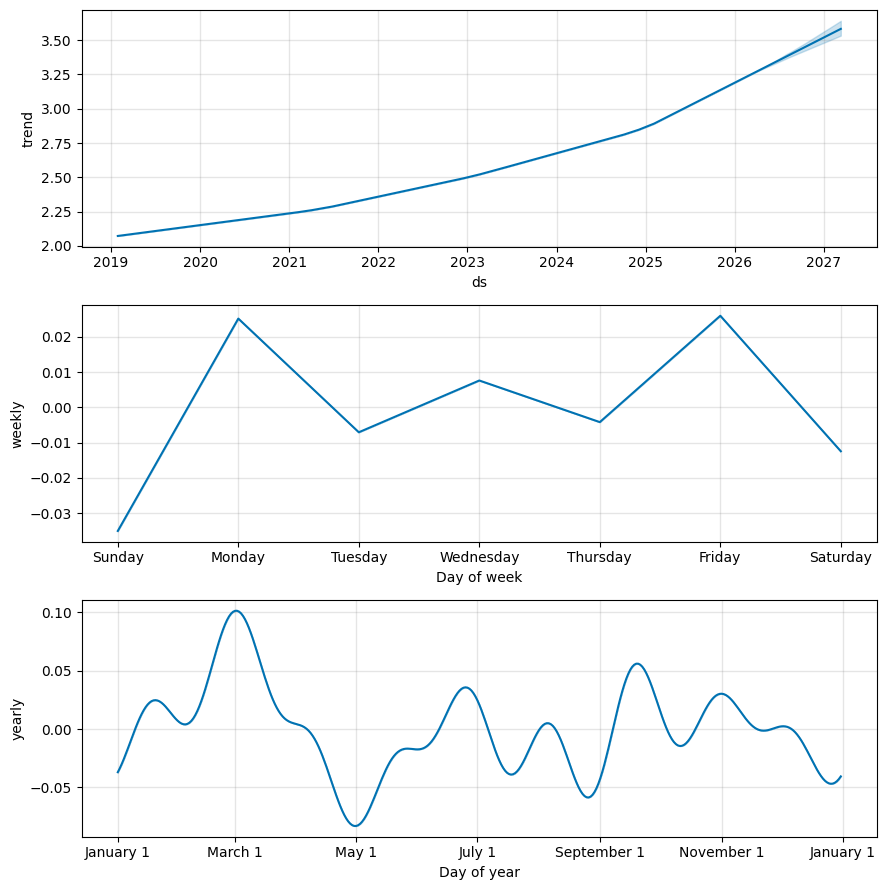

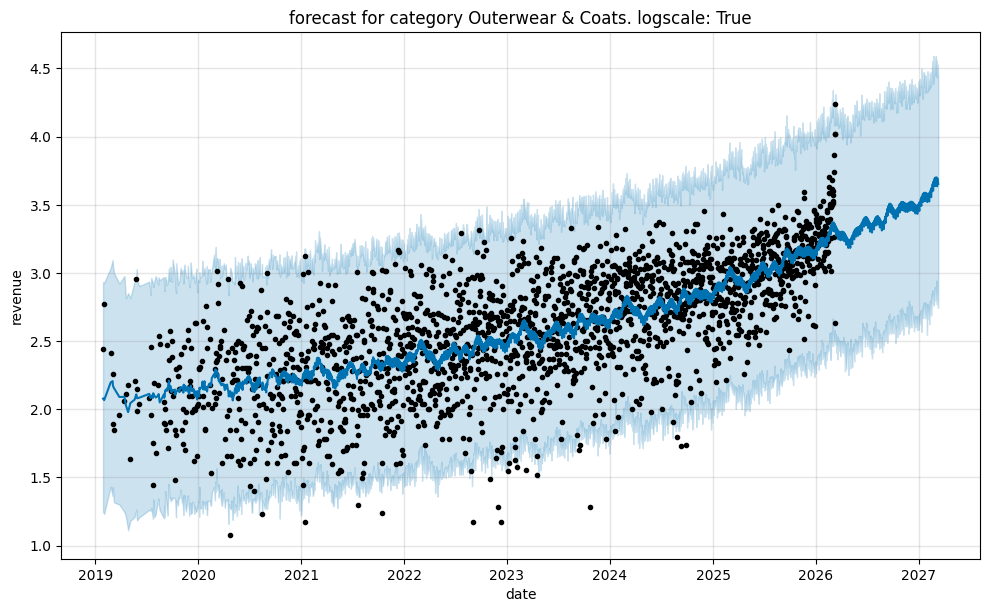

In [119]:
df_ = group_periodly(df, agg_col='category', datetime_col='created_at', period='D', target_col='revenue')
revenue_category_forecast_no_churn, _, _= get_forecast(df_[df_["category"] == "Outerwear & Coats"], agg_col='category', target_col='revenue', period='D', top=5, plot=True, plot_components=True, logscale=True)